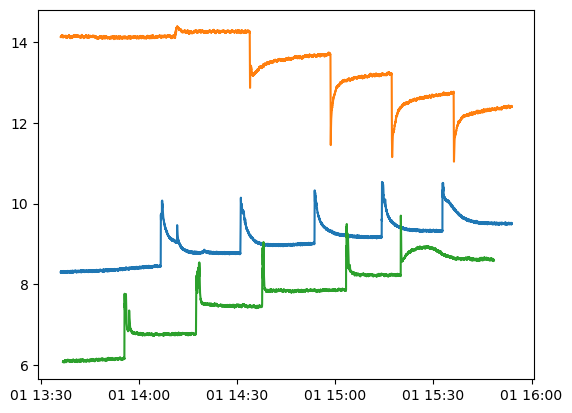

In [137]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from glob import glob

files = glob('*.csv')

# time,mixture cell P,reference cell P,mixture cell T,reference cell T
# for file in files:
#     df = pd.read_csv(file)
#     df['time'] = pd.to_datetime(df['time'])
#     plt.plot(df['time'], df['mixture cell P'])


In [138]:
df = pd.read_csv('station_4.csv')
df['time'] = pd.to_datetime(df['time'])

Detected 8 spikes and 8 settled points
Settled values: [14.2667301  14.27108808 13.66966885 13.66829922 13.18635422 13.19102377
 12.68570425 12.68951241]


Text(0, 0.5, 'y')

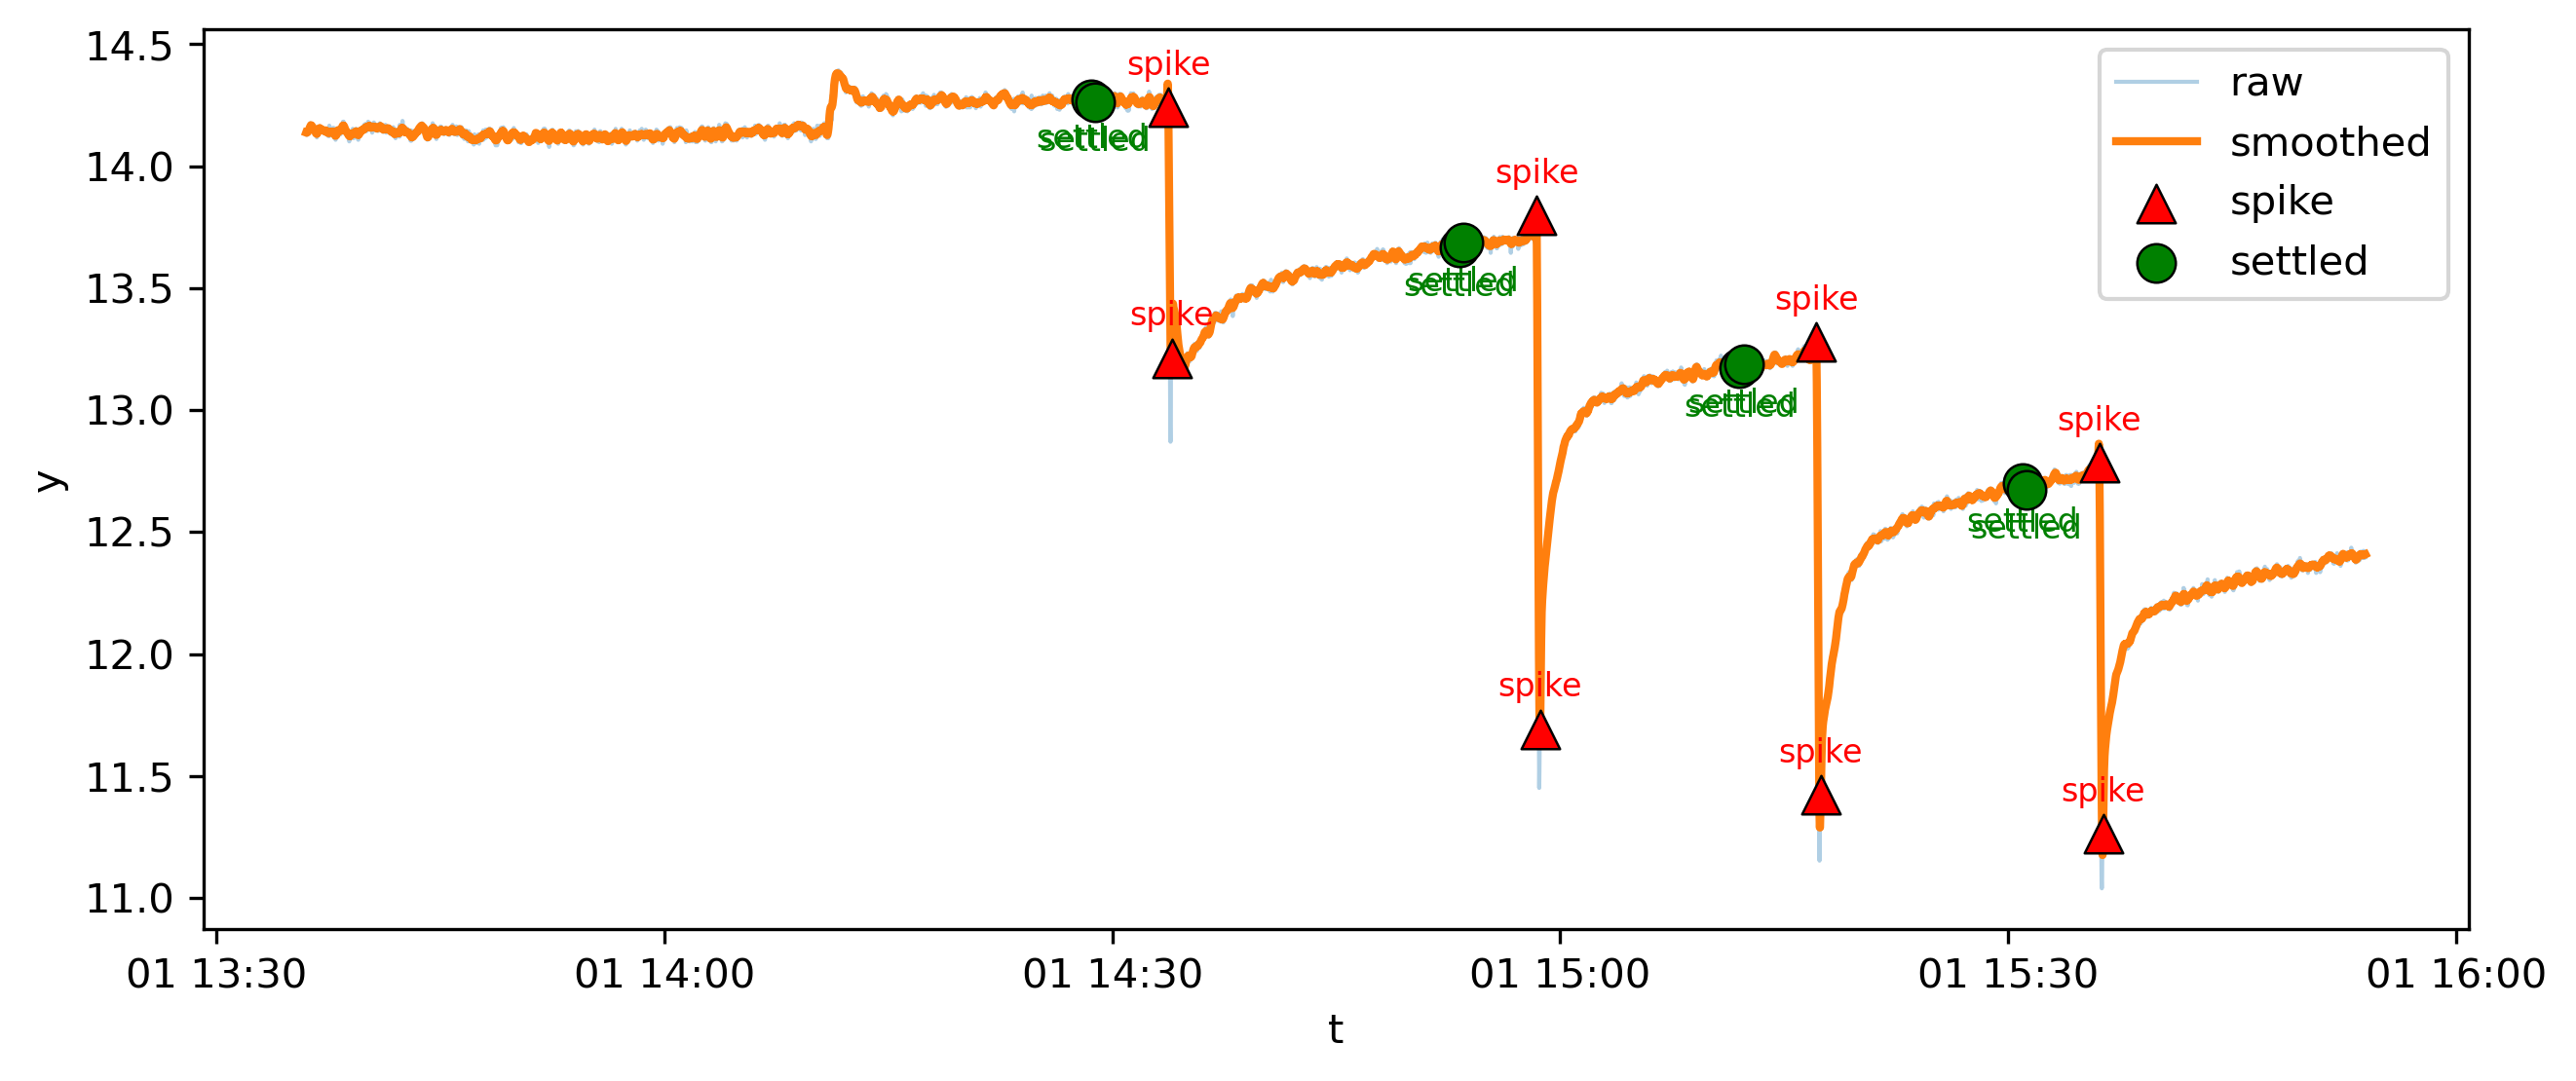

In [139]:
from scipy.signal import savgol_filter


def extract_settled_values(
    t,
    y,
    smooth_window=21,     
    polyorder=3,
    spike_thresh=0.05,    
):
    y_smooth = savgol_filter(y, smooth_window, polyorder)
    dy = np.gradient(y_smooth, t)
    spike_mask = np.abs(dy) > spike_thresh
    spike_indices = np.where(np.diff(spike_mask.astype(int)) == 1)[0] + 1

    settled_indices = []
    settled_values = []

    for s in spike_indices:
        t_spike = t[s]
        in_window = np.where((t >= t_spike - 980) & (t <= t_spike - 260))[0]  # 3–1 min before spike

        if in_window.size >= 100:
            chosen = in_window[-100:]  # take 100 closest points to 1 min before spike
        else:
            continue  
        settled_indices.append(chosen[len(chosen) // 2])  # representative index for plotting
        settled_values.append(np.mean(y_smooth[chosen]))

    return spike_indices, settled_indices, np.array(settled_values), y_smooth


t = df['time'].to_numpy()
y = df['mixture cell P'].to_numpy()

t_sec = (t - t[0]) / np.timedelta64(1, "s")
spikes, settles, values, y_smooth = extract_settled_values(t_sec, y)

print(f"Detected {len(spikes)} spikes and {len(settles)} settled points")
print("Settled values:", values)

fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
ax.plot(t, y, label="raw", alpha=0.35, linewidth=1)
ax.plot(t, y_smooth, label="smoothed", linewidth=2)

if len(spikes) > 0:
    ax.scatter(
        t[spikes],
        y_smooth[spikes],
        color="red",
        s=90,
        marker="^",
        edgecolor="black",
        linewidth=0.6,
        zorder=5,
        label="spike",
    )
    for idx in spikes:
        ax.annotate(
            "spike",
            (t[idx], y_smooth[idx]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=8,
            color="red",
        )

if len(settles) > 0:
    ax.scatter(
        t[settles],
        y_smooth[settles],
        color="green",
        s=90,
        marker="o",
        edgecolor="black",
        linewidth=0.6,
        zorder=5,
        label="settled",
    )
    for idx in settles:
        ax.annotate(
            "settled",
            (t[idx], y_smooth[idx]),
            textcoords="offset points",
            xytext=(0, -12),
            ha="center",
            fontsize=8,
            color="green",
        )

ax.legend()
ax.set_xlabel("t")
ax.set_ylabel("y")

In [140]:
window = 50  # points before/after each settled index

rows = []
n = len(y)

for s_idx in settles:
    start = max(0, s_idx - window)
    end = min(n, s_idx + window + 1)  # +1 because end is exclusive
    segment = y[start:end]

    rows.append(
        {
            "settled_index": int(s_idx),
            "time": t[s_idx],
            "start_idx": start,
            "end_idx": end - 1,
            "n_points": len(segment),
            "mean": float(np.mean(segment)),
            "std": float(np.std(segment, ddof=1)),
        }
    )

for s_idx in [len(y)-200]:
    start = max(0, s_idx - window)
    end = min(n, s_idx + window + 1)  # +1 because end is exclusive
    segment = y[start:end]

    rows.append(
        {
            "settled_index": int(s_idx),
            "time": t[s_idx],
            "start_idx": start,
            "end_idx": end - 1,
            "n_points": len(segment),
            "mean": float(np.mean(segment)),
            "std": float(np.std(segment, ddof=1)),
        }
    )


settled_stats = pd.DataFrame(rows)
settled_stats.to_clipboard(excel=True)
settled_stats

,settled_index,time,start_idx,end_idx,n_points,mean,std
0,3154,1900-01-01 14:28:35.946461,3104,3204,101,14.266805,0.014263
1,3168,1900-01-01 14:28:49.954616,3118,3218,101,14.270975,0.013821
2,4633,1900-01-01 14:53:15.440970,4583,4683,101,13.669710,0.013813
3,4648,1900-01-01 14:53:30.444966,4598,4698,101,13.668491,0.013421
4,5757,1900-01-01 15:11:59.820298,5707,5807,101,13.186177,0.016814
5,5775,1900-01-01 15:12:17.828079,5725,5825,101,13.191149,0.015269
6,6894,1900-01-01 15:30:57.178829,6844,6944,101,12.685769,0.011812
7,6909,1900-01-01 15:31:12.178905,6859,6959,101,12.689715,0.011833
8,8073,1900-01-01 15:50:36.596222,8023,8123,101,12.367477,0.015951


In [141]:
settles

[3154, 3168, 4633, 4648, 5757, 5775, 6894, 6909]

In [144]:
y[:100].std()

0.012337382257188787